# Imports

In [1]:
import datetime

import numpy as np
import pandas as pd
import glob
import random
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from scipy.stats import norm
import matplotlib.pyplot as plt

C:\Users\marce\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Bayesian Linear Regression Model

In [2]:
class BayesianLinearRegression:
    def __init__(self, alpha=1.0, beta=1.0):
        self.alpha = alpha  # Prior precision
        self.beta = beta    # Noise precision
        self.m_N = None     # Posterior mean
        self.S_N = None     # Posterior covariance

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        n_features = X.shape[1]
        I = np.eye(n_features)
        A = self.alpha * I + self.beta * X.T @ X
        self.S_N = np.linalg.solve(A, I)
        self.m_N = self.beta * self.S_N @ X.T @ y

    def predict(self, X, return_std=False):
        X = np.asarray(X)
        y_mean = X @ self.m_N
        if return_std:
            y_var = 1 / self.beta + np.sum(X @ self.S_N * X, axis=1)
            y_std = np.sqrt(y_var)
            return y_mean, y_std
        return y_mean

# Function for running and evaluating multiple runs of model training and testing

In [3]:
def run_multiple_experiments(n_runs=10, train_size_ratio=0.8, normalize=True, optimize_hyperparameters=True):
    metrics = {
        'start_accuracy': [], 'mid_accuracy': [], 'end_accuracy': [],
        'start_mae': [], 'mid_mae': [], 'end_mae': []
    }

    numerical_cols = [
        'tyre_wear_rear_left', 'tyre_wear_rear_right', 'tyre_wear_front_left', 'tyre_wear_front_right',
        'fuel_in_tank', 'ers_store_energy', 'tyre_surface_temp_rear_left', 'tyre_surface_temp_rear_right',
        'tyre_surface_temp_front_left', 'tyre_surface_temp_front_right', 'tyre_inner_temp_rear_left',
        'tyre_inner_temp_rear_right', 'tyre_inner_temp_front_left', 'tyre_inner_temp_front_right',
        'tyre_pressure_rear_left', 'tyre_pressure_rear_right', 'tyre_pressure_front_left',
        'tyre_pressure_front_right', 'lap_distance', 'last_lap_ms', 'sector_1_ms', 'sector_2_ms',
        'delta_in_front_ms', 'delta_leader_ms', 'track_temp', 'air_temp', 'penalties_time'
    ]

    drop_cols = ['finishing_position', 'actual_tyre_compound', 'visual_tyre_compound']

    # Lap splits
    total_laps = 14
    start_laps = int(0.3 * total_laps)              # ~4 laps
    end_laps = int(0.3 * total_laps)                # ~4 laps
    mid_laps = total_laps - start_laps - end_laps   # ~6 laps

    for run in range(n_runs):
        random.seed(run)

        files = glob.glob('*.csv')
        random.shuffle(files)

        def process_tyre_compound(df):
            df['is_soft_compound'] = df['visual_tyre_compound'] == 16
            df['is_medium_compound'] = df['visual_tyre_compound'] == 17
            df['is_hard_compound'] = df['visual_tyre_compound'] == 18

            df = df.drop('visual_tyre_compound', axis=1)
            return df

        # Split files
        train_size = int(train_size_ratio * len(files))
        train_files = files[:train_size]
        test_files = files[train_size:]

        df_train = pd.DataFrame()
        for filename in train_files:
            df = pd.read_csv(filename)
            df = process_tyre_compound(df)
            df[df.select_dtypes(include='bool').columns] = df.select_dtypes(include='bool').astype(int)
            df_train = pd.concat([df_train, df])

        # Split races in 3 stages
        df_test_start = pd.DataFrame()
        df_test_mid = pd.DataFrame()
        df_test_end = pd.DataFrame()

        for filename in test_files:
            df = pd.read_csv(filename)
            df = process_tyre_compound(df)
            df[df.select_dtypes(include='bool').columns] = df.select_dtypes(include='bool').astype(int)
            df_start = df[df['current_lap'] <= start_laps]
            df_mid = df[(df['current_lap'] > start_laps) & (df['current_lap'] <= start_laps + mid_laps)]
            df_end = df[df['current_lap'] > start_laps + mid_laps]
            df_test_start = pd.concat([df_test_start, df_start])
            df_test_mid = pd.concat([df_test_mid, df_mid])
            df_test_end = pd.concat([df_test_end, df_end])

        # Prepare data
        X_train = df_train.drop(columns=drop_cols, errors='ignore')
        y_train = df_train['finishing_position']
        X_test_start = df_test_start.drop(columns=drop_cols, errors='ignore')
        y_test_start = df_test_start['finishing_position']
        X_test_mid = df_test_mid.drop(columns=drop_cols, errors='ignore')
        y_test_mid = df_test_mid['finishing_position']
        X_test_end = df_test_end.drop(columns=drop_cols, errors='ignore')
        y_test_end = df_test_end['finishing_position']

        # Normalize
        if normalize:
            scaler = StandardScaler()
            X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
            X_test_start[numerical_cols] = scaler.transform(X_test_start[numerical_cols])
            X_test_mid[numerical_cols] = scaler.transform(X_test_mid[numerical_cols])
            X_test_end[numerical_cols] = scaler.transform(X_test_end[numerical_cols])

        # Hyperparameter optimization
        if optimize_hyperparameters:
            optuna.logging.set_verbosity(optuna.logging.ERROR)
            def objective(trial, X_train, y_train, X_val, y_val):
                alpha = trial.suggest_float('alpha', 1e-3, 1e3, log=True)
                beta = trial.suggest_float('beta', 1e-3, 1e3, log=True)
                model = BayesianLinearRegression(alpha=alpha, beta=beta)
                model.fit(X_train, y_train)
                preds, std = model.predict(X_val, return_std=True)
                mae = mean_absolute_error(y_val, preds)
                nlpd = -np.mean(norm.logpdf(y_val, loc=preds, scale=std))
                return mae + 0.1 * nlpd

            X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
            study = optuna.create_study(direction='minimize')
            study.optimize(lambda trial: objective(trial, X_train_sub, y_train_sub, X_val, y_val), n_trials=50)
            best_alpha, best_beta = study.best_params['alpha'], study.best_params['beta']
        else:
            best_alpha, best_beta = 1.0, 1.0

        # Train model
        model = BayesianLinearRegression(alpha=best_alpha, beta=best_beta)
        model.fit(X_train, y_train)

        # Evaluate splits
        def compute_accuracy(model, X_test, y_test):
            y_pred, _ = model.predict(X_test, return_std=True)
            y_pred_discrete = np.clip(np.round(y_pred), 1, 20).astype(int)
            y_test = y_test.astype(int)
            accuracy = np.mean(y_pred_discrete == y_test) * 100
            return accuracy

        def evaluate_regression_model(model, X_test, y_test, return_std=True):
            y_pred, y_std = model.predict(X_test, return_std=True)
            mae = mean_absolute_error(y_test, y_pred)
            accuracy = compute_accuracy(model, X_test, y_test)
            return mae, accuracy

        mae_start, acc_start = evaluate_regression_model(model, X_test_start, y_test_start)
        mae_mid, acc_mid = evaluate_regression_model(model, X_test_mid, y_test_mid)
        mae_end, acc_end = evaluate_regression_model(model, X_test_end, y_test_end)

        # Store split metrics
        metrics['start_accuracy'].append(acc_start)
        metrics['mid_accuracy'].append(acc_mid)
        metrics['end_accuracy'].append(acc_end)
        metrics['start_mae'].append(mae_start)
        metrics['mid_mae'].append(mae_mid)
        metrics['end_mae'].append(mae_end)

        # Single test race
        test_race_file = test_files[0]
        df_race = pd.read_csv(test_race_file)
        df_race = process_tyre_compound(df_race)
        df_race[df_race.select_dtypes(include='bool').columns] = df_race.select_dtypes(include='bool').astype(int)
        X_race = df_race.drop(columns=drop_cols, errors='ignore')
        y_race = df_race['finishing_position']

        if normalize:
            X_race[numerical_cols] = scaler.transform(X_race[numerical_cols])

        # Split test race into start, mid, end for final run
        df_race_start = df_race[df_race['current_lap'] <= start_laps]
        df_race_mid = df_race[(df_race['current_lap'] > start_laps) & (df_race['current_lap'] <= start_laps + mid_laps)]
        df_race_end = df_race[df_race['current_lap'] > start_laps + mid_laps]

        X_race_start = df_race_start.drop(columns=drop_cols, errors='ignore')
        X_race_mid = df_race_mid.drop(columns=drop_cols, errors='ignore')
        X_race_end = df_race_end.drop(columns=drop_cols, errors='ignore')

        if normalize:
            X_race_start[numerical_cols] = scaler.transform(X_race_start[numerical_cols])
            X_race_mid[numerical_cols] = scaler.transform(X_race_mid[numerical_cols])
            X_race_end[numerical_cols] = scaler.transform(X_race_end[numerical_cols])

        y_pred, y_std = model.predict(X_race, return_std=True)

        actual_position = y_race.iloc[0]
        pred_continuous = np.average(y_pred, weights=1/(y_std**2))
        pred_discrete = int(np.clip(np.round(pred_continuous), 1, 20))
        uncertainty_std = np.mean(y_std)

        # Store final run data for plotting and segment predictions
        if run == n_runs - 1:
            final_model = model
            final_X_train = X_train
            # Compute segment predictions
            if not df_race_start.empty:
                y_pred_start, y_std_start = model.predict(X_race_start, return_std=True)
                pred_continuous_start = np.average(y_pred_start, weights=1/(y_std_start**2))
                pred_discrete_start = int(np.clip(np.round(pred_continuous_start), 1, 20))
                uncertainty_std_start = np.mean(y_std_start)
            else:
                y_pred_start, y_std_start = np.array([]), np.array([])
                pred_continuous_start, pred_discrete_start, uncertainty_std_start = np.nan, np.nan, np.nan

            if not df_race_mid.empty:
                y_pred_mid, y_std_mid = model.predict(X_race_mid, return_std=True)
                pred_continuous_mid = np.average(y_pred_mid, weights=1/(y_std_mid**2))
                pred_discrete_mid = int(np.clip(np.round(pred_continuous_mid), 1, 20))
                uncertainty_std_mid = np.mean(y_std_mid)
            else:
                y_pred_mid, y_std_mid = np.array([]), np.array([])
                pred_continuous_mid, pred_discrete_mid, uncertainty_std_mid = np.nan, np.nan, np.nan

            if not df_race_end.empty:
                y_pred_end, y_std_end = model.predict(X_race_end, return_std=True)
                pred_continuous_end = np.average(y_pred_end, weights=1/(y_std_end**2))
                pred_discrete_end = int(np.clip(np.round(pred_continuous_end), 1, 20))
                uncertainty_std_end = np.mean(y_std_end)
            else:
                y_pred_end, y_std_end = np.array([]), np.array([])
                pred_continuous_end, pred_discrete_end, uncertainty_std_end = np.nan, np.nan, np.nan

            final_test_race_results = {
                'file': test_race_file,
                'actual': actual_position,
                'continuous': pred_continuous,
                'discrete': pred_discrete,
                'uncertainty': uncertainty_std,
                'y_pred_race': y_pred,
                'y_std_race': y_std,
                'start_continuous': pred_continuous_start,
                'start_discrete': pred_discrete_start,
                'start_uncertainty': uncertainty_std_start,
                'y_pred_start': y_pred_start,
                'y_std_start': y_std_start,
                'mid_continuous': pred_continuous_mid,
                'mid_discrete': pred_discrete_mid,
                'mid_uncertainty': uncertainty_std_mid,
                'y_pred_mid': y_pred_mid,
                'y_std_mid': y_std_mid,
                'end_continuous': pred_continuous_end,
                'end_discrete': pred_discrete_end,
                'end_uncertainty': uncertainty_std_end,
                'y_pred_end': y_pred_end,
                'y_std_end': y_std_end
            }

    # Compute mean and std for metrics
    summary = {}
    for key, values in metrics.items():
        summary[f'{key}_mean'] = np.mean(values)
        summary[f'{key}_std'] = np.std(values)

    # Print summary table
    print("\nExperiment Summary (Mean ± Std):")
    print(f"Start Laps Accuracy: {summary['start_accuracy_mean']:.2f}% ± {summary['start_accuracy_std']:.2f}%")
    print(f"Mid Laps Accuracy: {summary['mid_accuracy_mean']:.2f}% ± {summary['mid_accuracy_std']:.2f}%")
    print(f"End Laps Accuracy: {summary['end_accuracy_mean']:.2f}% ± {summary['end_accuracy_std']:.2f}%")
    print(f"Start Laps MAE: {summary['start_mae_mean']:.2f} ± {summary['start_mae_std']:.2f}")
    print(f"Mid Laps MAE: {summary['mid_mae_mean']:.2f} ± {summary['mid_mae_std']:.2f}")
    print(f"End Laps MAE: {summary['end_mae_mean']:.2f} ± {summary['end_mae_std']:.2f}")

    # Run final evaluation and plots for the last run
    def evaluate_regression_model_with_plot(model, X_test, y_test, title, return_std=True):
        y_pred, y_std = model.predict(X_test, return_std=True)
        mae = mean_absolute_error(y_test, y_pred)
        accuracy = compute_accuracy(model, X_test, y_test)

        plt.figure(figsize=(8, 6))
        plt.errorbar(y_test, y_pred, yerr=y_std, fmt='o', color='blue', alpha=0.5, label='Predictions ± Std')
        plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', label='Ideal')
        plt.xlabel('True Finishing Position')
        plt.ylabel('Predicted Finishing Position')
        plt.title(f'{title} Predictions')
        plt.legend()
        plt.grid(True)
        plt.text(min(y_test)*1.05, max(y_test)*0.95,
                 f'MAE: {mae:.2f}\nAccuracy: {accuracy:.2f}%',
                 fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
        plt.tight_layout()
        plt.show()
        return mae, accuracy

    # Evaluate final run
    mae_start, acc_start = evaluate_regression_model_with_plot(
        final_model, X_test_start, y_test_start, 'Start Laps')
    mae_mid, acc_mid = evaluate_regression_model_with_plot(
        final_model, X_test_mid, y_test_mid, 'Mid Laps')
    mae_end, acc_end = evaluate_regression_model_with_plot(
        final_model, X_test_end, y_test_end, 'End Laps')

    # Print final test race results with segment predictions
    print("\nFinal Run Test Race Results:")
    print(f"Test Race: {final_test_race_results['file']}")
    print(f"Actual Finishing Position: {final_test_race_results['actual']}")
    print()
    print(f"Overall Continuous: {final_test_race_results['continuous']:.3f}")
    print(f"Overall Discrete: {final_test_race_results['discrete']}")
    print(f"Overall Uncertainty: {final_test_race_results['uncertainty']:.3f}")
    print()
    print(f"Start Continuous: {final_test_race_results['start_continuous']:.3f} ± {final_test_race_results['start_uncertainty']:.3f}")
    print(f"Start Discrete: {final_test_race_results['start_discrete']}")
    print()
    print(f"Mid Continuous: {final_test_race_results['mid_continuous']:.3f} ± {final_test_race_results['mid_uncertainty']:.3f}")
    print(f"Mid Discrete: {final_test_race_results['mid_discrete']}")
    print()
    print(f"End Continuous: {final_test_race_results['end_continuous']:.3f} ± {final_test_race_results['end_uncertainty']:.3f}")
    print(f"End Discrete: {final_test_race_results['end_discrete']}")

    # Plot feature importance for final run
    plt.figure(figsize=(10, 6))
    weights = final_model.m_N
    features = final_X_train.columns
    plt.bar(features, np.abs(weights))
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Features')
    plt.ylabel('Absolute Posterior Weight')
    plt.title('Feature Importance (Posterior Weights)')
    plt.tight_layout()
    plt.show()

    # Plot MAE across splits for final run
    plt.figure(figsize=(6, 4))
    splits = ['Start', 'Mid', 'End']
    maes = [mae_start, mae_mid, mae_end]
    plt.bar(splits, maes, color=['blue', 'green', 'red'])
    plt.xlabel('Race Segment')
    plt.ylabel('Mean Absolute Error')
    plt.title('MAE Across Race Segments')
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

    # Function to plot predicted position vs probability
    def plot_combined_position_probabilities(results, race_file):
        positions = np.arange(1, 21)

        segments = [
            ('Overall Race', results['y_pred_race'], results['y_std_race'], 'purple'),
            ('Start Segment', results['y_pred_start'], results['y_std_start'], 'blue'),
            ('Mid Segment', results['y_pred_mid'], results['y_std_mid'], 'green'),
            ('End Segment', results['y_pred_end'], results['y_std_end'], 'orange'),
        ]

        bar_width = 0.2
        offset = [-1.5, -0.5, 0.5, 1.5]

        plt.figure(figsize=(10, 6))

        for i, (label, y_pred, y_std, color) in enumerate(segments):
            probabilities = np.zeros(len(positions))
            for j, pos in enumerate(positions):
                probabilities[j] = np.mean(norm.pdf(pos, loc=y_pred, scale=y_std))
            probabilities = probabilities / np.sum(probabilities)

            pos_shifted = positions + bar_width * offset[i]
            plt.bar(pos_shifted, probabilities, width=bar_width, color=color, alpha=0.7, label=label)

        plt.xlabel('Predicted Finishing Position')
        plt.ylabel('Probability')
        plt.title(f'Predicted Position vs Probability ({race_file})')
        plt.grid(True, axis='y')
        plt.xticks(positions)
        plt.legend()
        plt.tight_layout()
        plt.show()

    plot_combined_position_probabilities(final_test_race_results, final_test_race_results['file'])

# Unnormalized data, static alpha and beta parameters


Experiment Summary (Mean ± Std):
Start Laps Accuracy: 19.91% ± 15.02%
Mid Laps Accuracy: 23.18% ± 12.03%
End Laps Accuracy: 27.24% ± 15.25%
Start Laps MAE: 1.94 ± 0.58
Mid Laps MAE: 1.76 ± 0.51
End Laps MAE: 1.44 ± 0.52


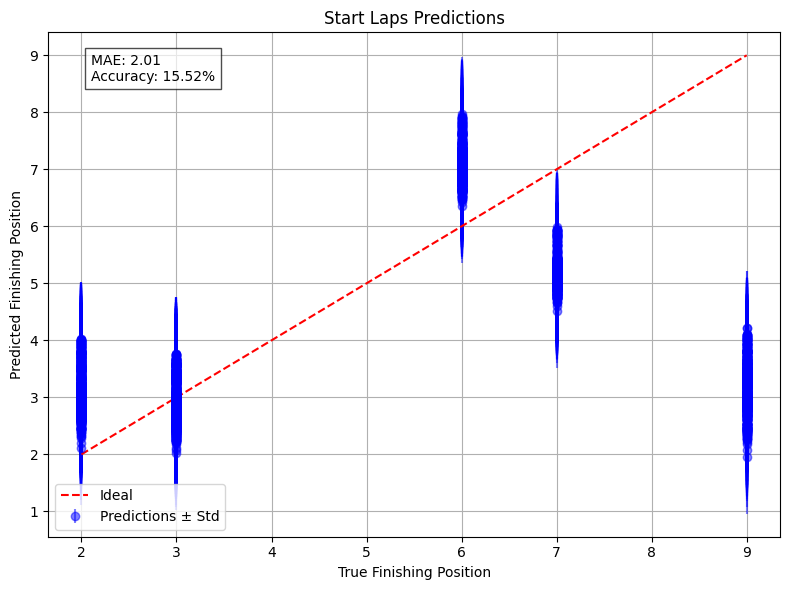

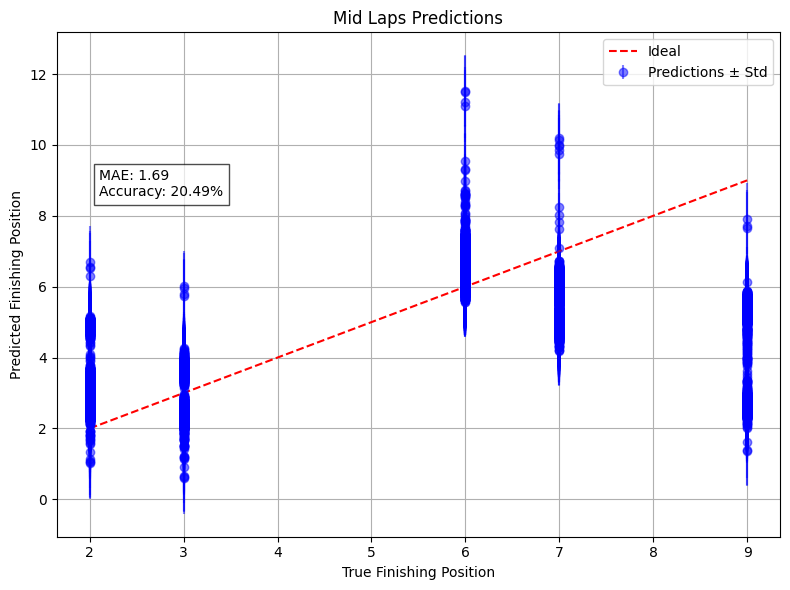

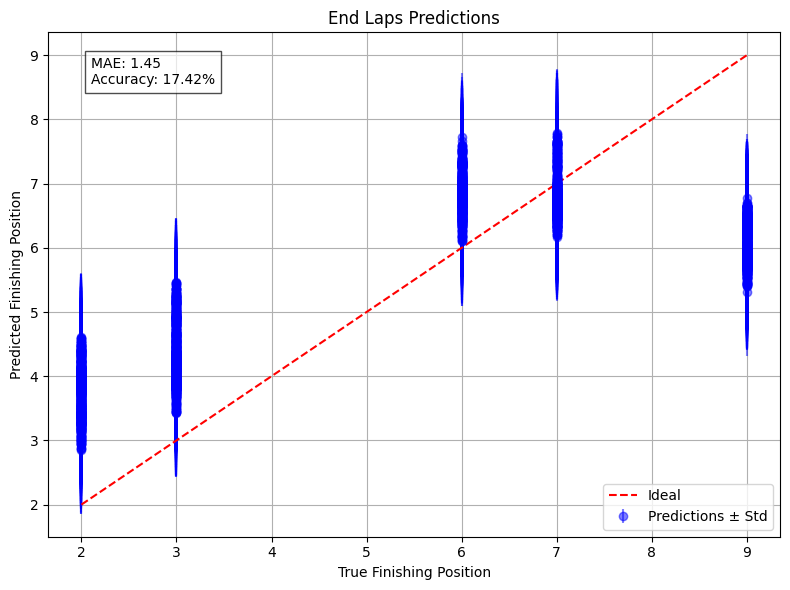


Final Run Test Race Results:
Test Race: 2025-06-04_17-03-39.csv
Actual Finishing Position: 6

Overall Continuous: 6.791
Overall Discrete: 7
Overall Uncertainty: 1.001

Start Continuous: 7.077 ± 1.000
Start Discrete: 7

Mid Continuous: 6.559 ± 1.001
Mid Discrete: 7

End Continuous: 6.858 ± 1.001
End Discrete: 7


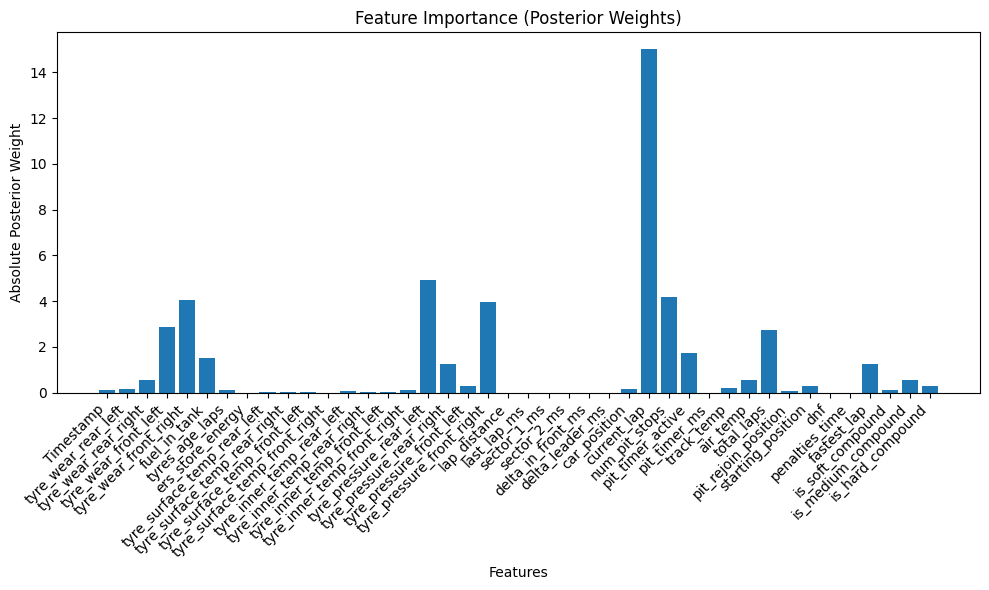

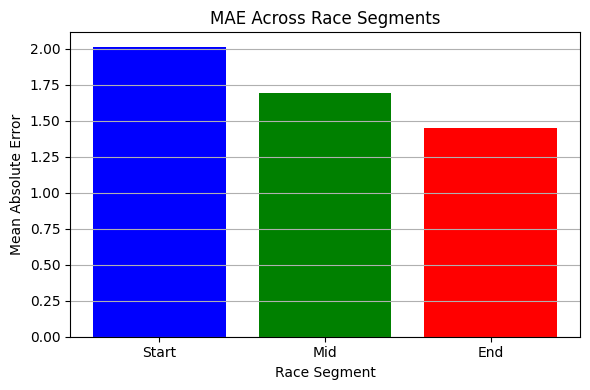

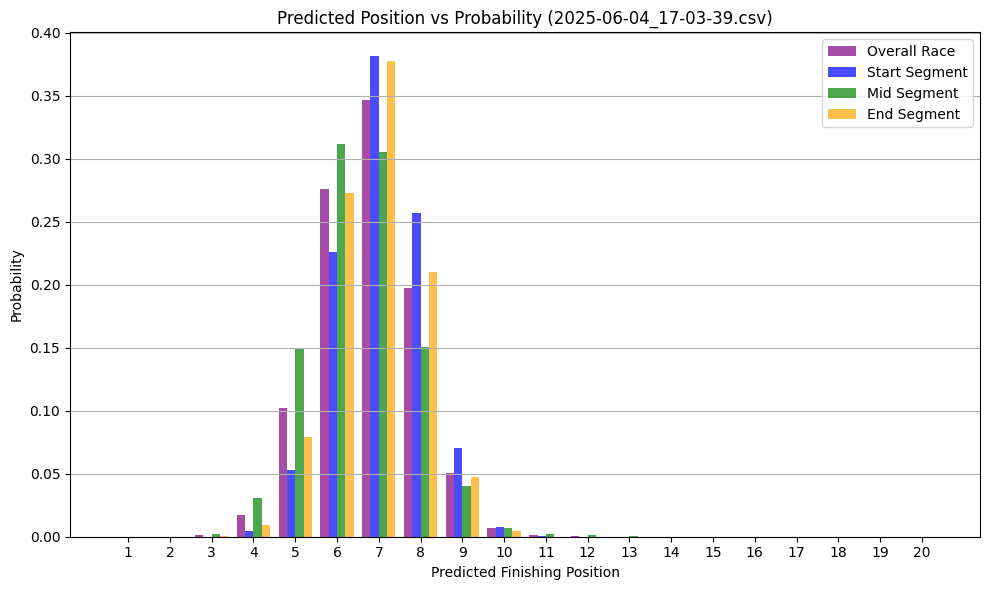

In [4]:
run_multiple_experiments(n_runs=100, train_size_ratio=0.8, normalize=False, optimize_hyperparameters=False)

# Unnormalized data, optimized alpha and beta parameters


Experiment Summary (Mean ± Std):
Start Laps Accuracy: 19.82% ± 14.87%
Mid Laps Accuracy: 23.34% ± 11.99%
End Laps Accuracy: 27.32% ± 15.33%
Start Laps MAE: 1.95 ± 0.58
Mid Laps MAE: 1.76 ± 0.51
End Laps MAE: 1.45 ± 0.52


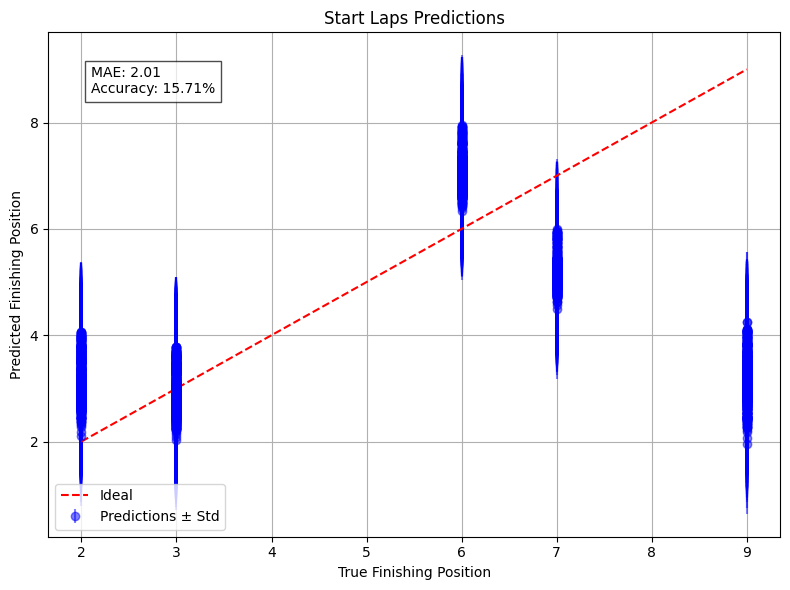

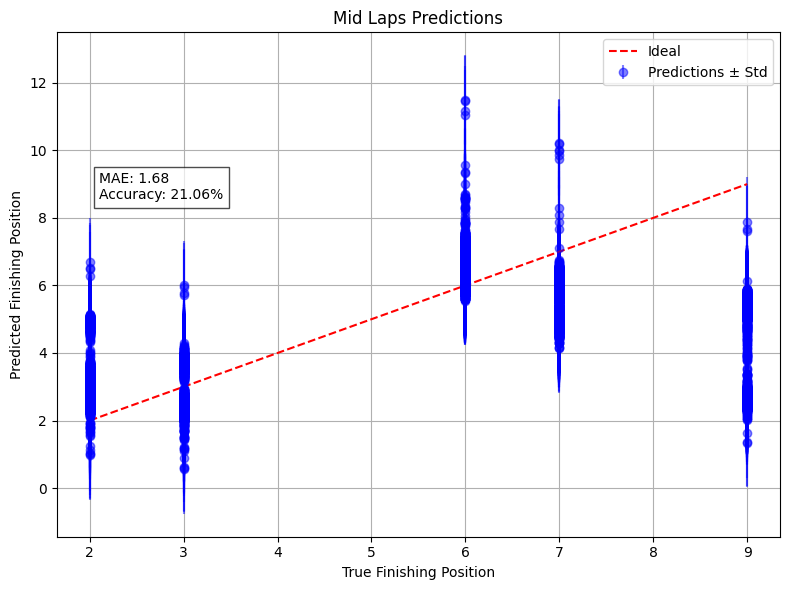

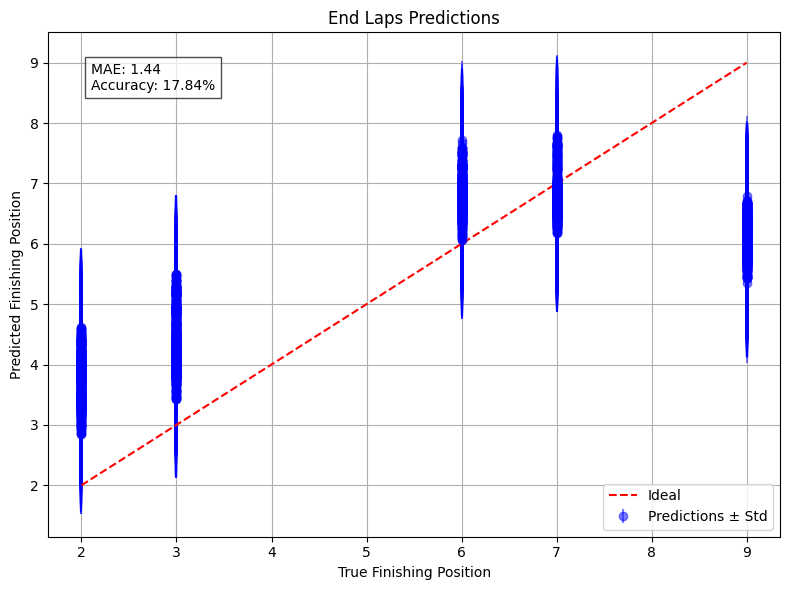


Final Run Test Race Results:
Test Race: 2025-06-04_17-03-39.csv
Actual Finishing Position: 6

Overall Continuous: 6.771
Overall Discrete: 7
Overall Uncertainty: 1.314

Start Continuous: 7.063 ± 1.313
Start Discrete: 7

Mid Continuous: 6.537 ± 1.314
Mid Discrete: 7

End Continuous: 6.835 ± 1.314
End Discrete: 7


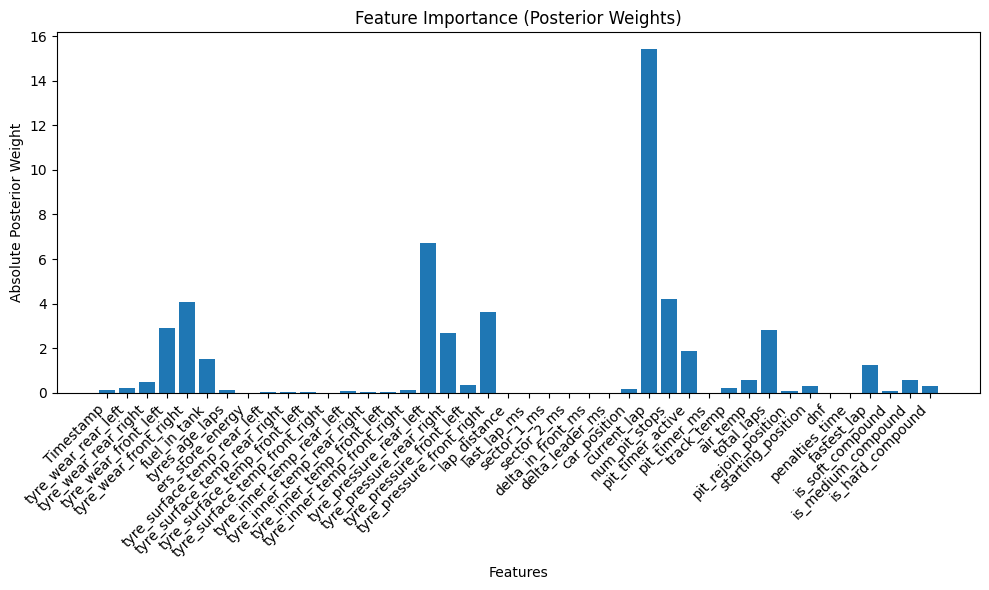

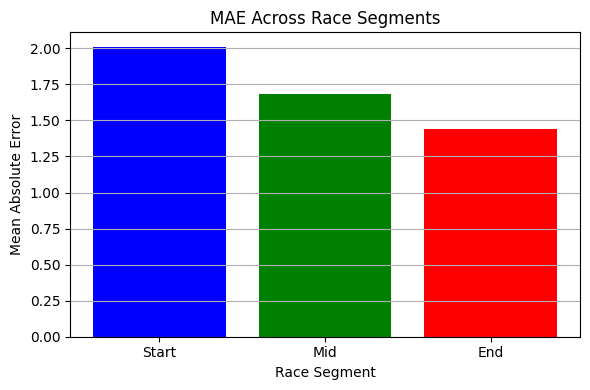

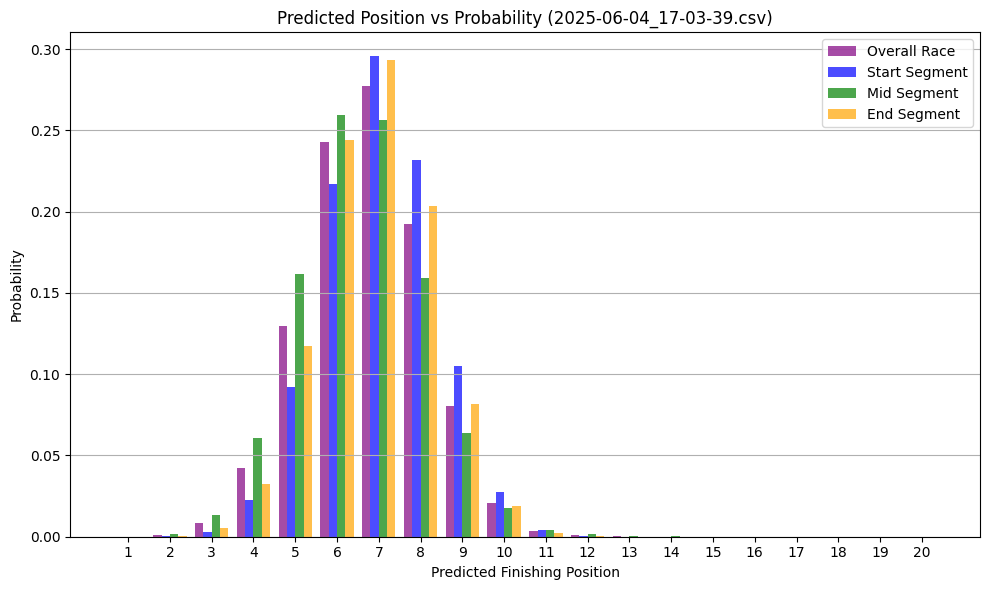

In [5]:
run_multiple_experiments(n_runs=100, train_size_ratio=0.8, normalize=False, optimize_hyperparameters=True)

# Normalized data, unoptimized alpha and beta parameters


Experiment Summary (Mean ± Std):
Start Laps Accuracy: 19.98% ± 15.12%
Mid Laps Accuracy: 23.63% ± 12.18%
End Laps Accuracy: 27.68% ± 15.29%
Start Laps MAE: 1.92 ± 0.58
Mid Laps MAE: 1.73 ± 0.50
End Laps MAE: 1.42 ± 0.48


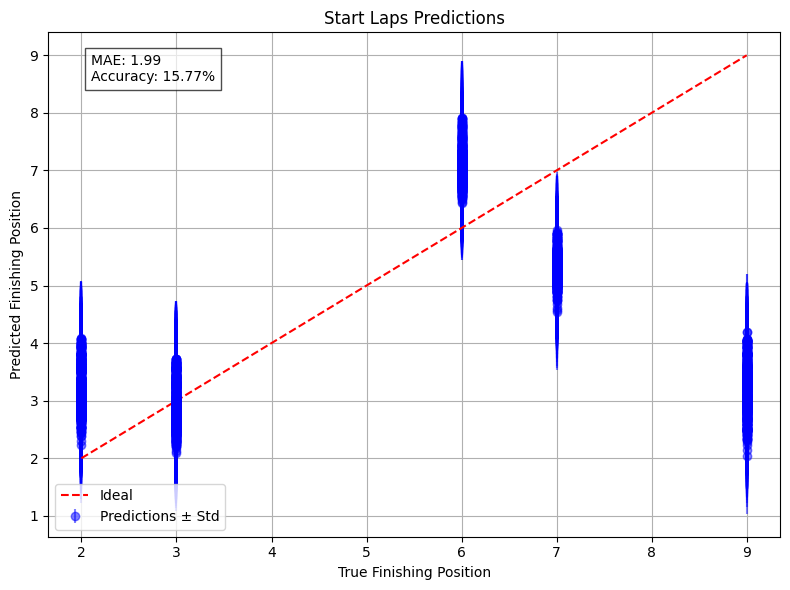

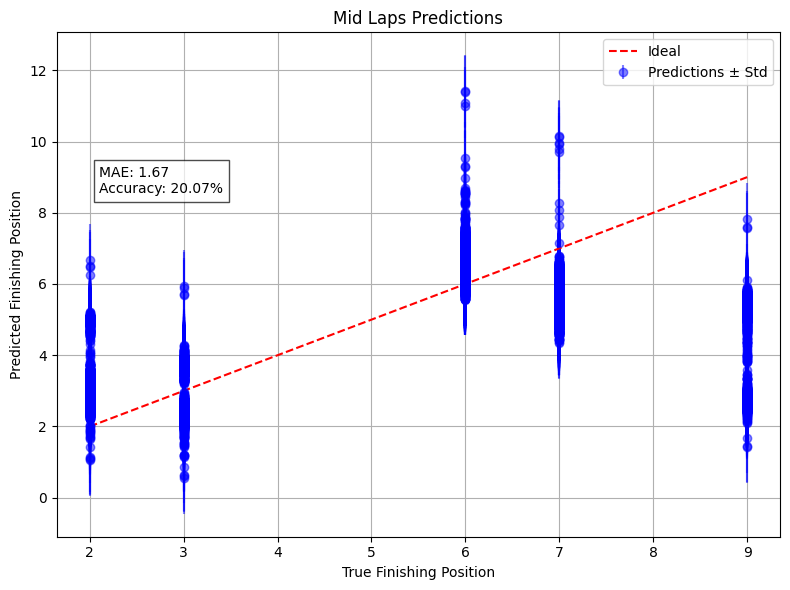

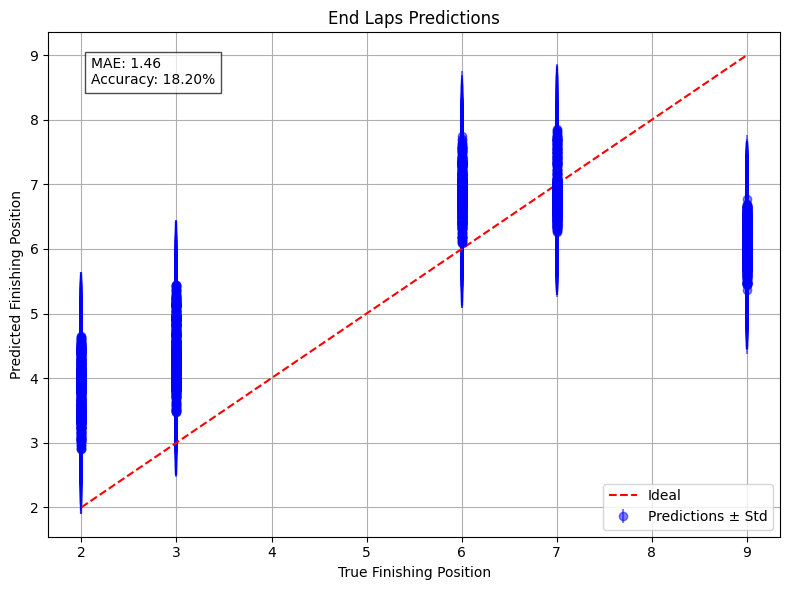


Final Run Test Race Results:
Test Race: 2025-06-04_17-03-39.csv
Actual Finishing Position: 6

Overall Continuous: 6.778
Overall Discrete: 7
Overall Uncertainty: 1.001

Start Continuous: 7.072 ± 1.000
Start Discrete: 7

Mid Continuous: 6.526 ± 1.001
Mid Discrete: 7

End Continuous: 6.875 ± 1.001
End Discrete: 7


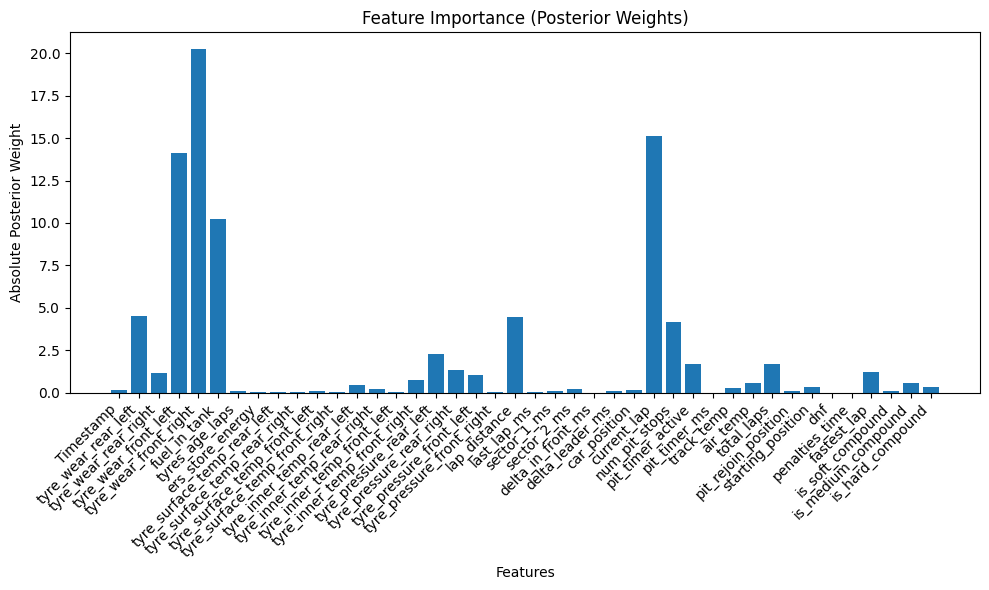

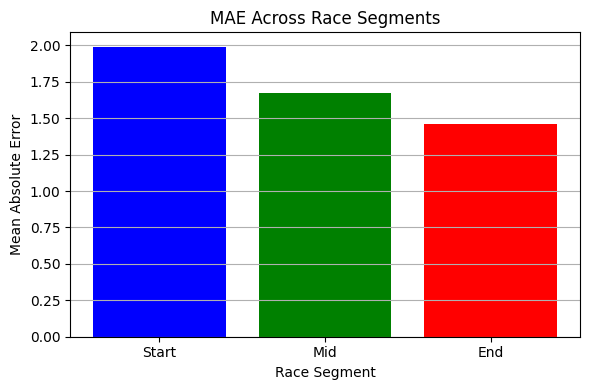

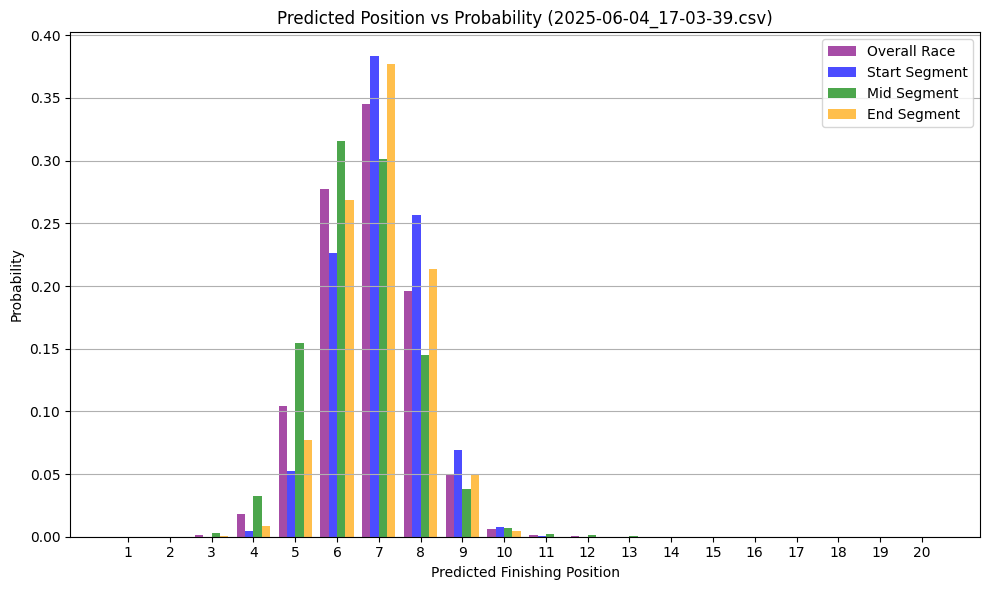

In [6]:
run_multiple_experiments(n_runs=100, train_size_ratio=0.8, normalize=True, optimize_hyperparameters=False)

# Normalized data, optimized alpha and beta parameters


Experiment Summary (Mean ± Std):
Start Laps Accuracy: 19.82% ± 14.80%
Mid Laps Accuracy: 23.40% ± 11.98%
End Laps Accuracy: 27.33% ± 15.35%
Start Laps MAE: 1.94 ± 0.58
Mid Laps MAE: 1.75 ± 0.51
End Laps MAE: 1.44 ± 0.51


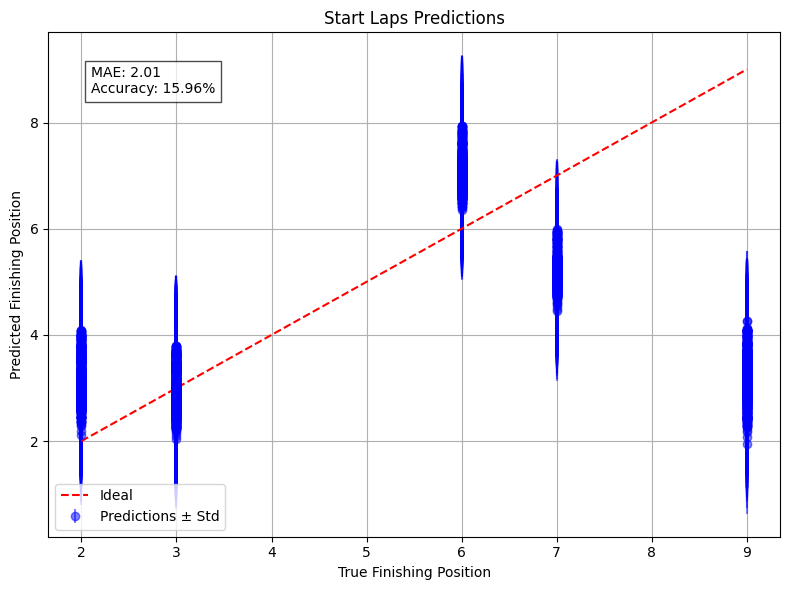

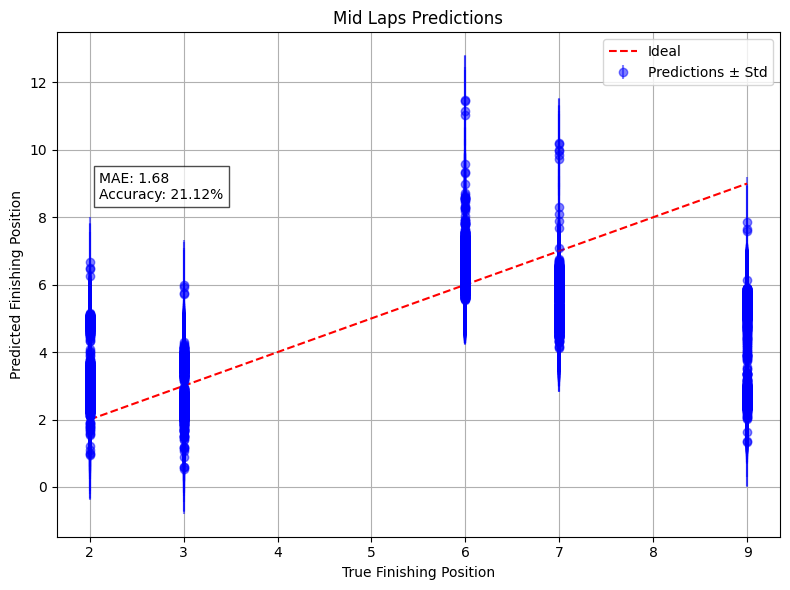

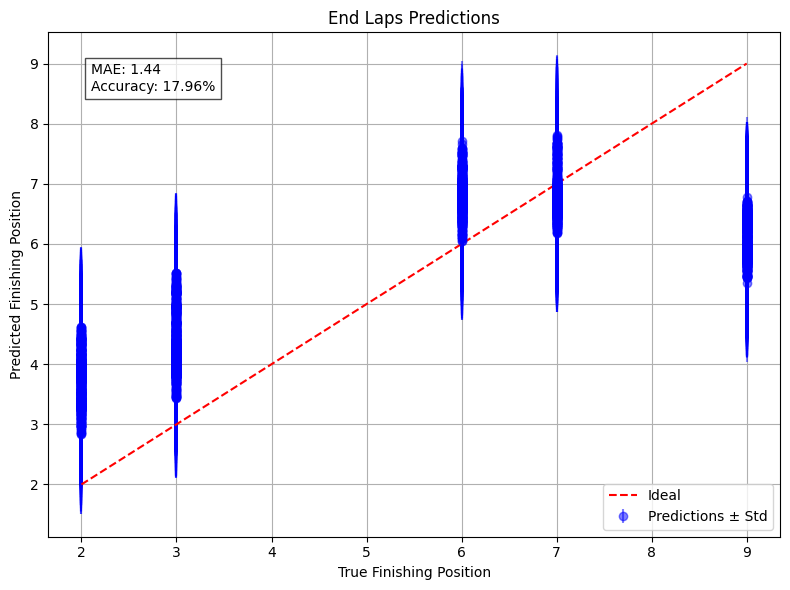


Final Run Test Race Results:
Test Race: 2025-06-04_17-03-39.csv
Actual Finishing Position: 6

Overall Continuous: 6.766
Overall Discrete: 7
Overall Uncertainty: 1.323

Start Continuous: 7.060 ± 1.323
Start Discrete: 7

Mid Continuous: 6.530 ± 1.323
Mid Discrete: 7

End Continuous: 6.833 ± 1.323
End Discrete: 7


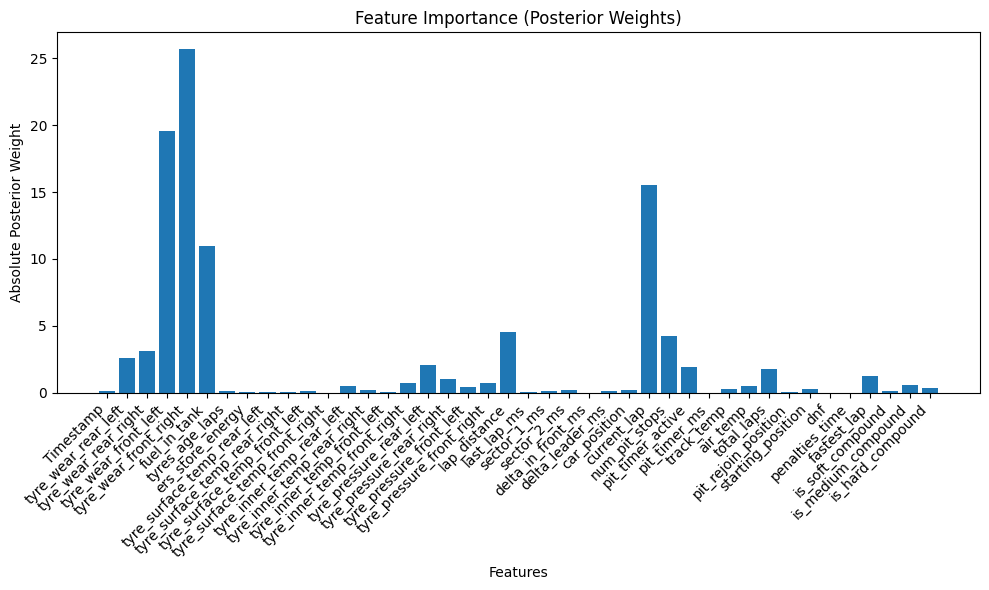

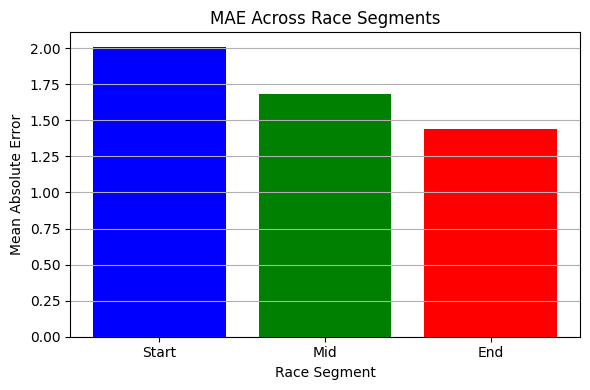

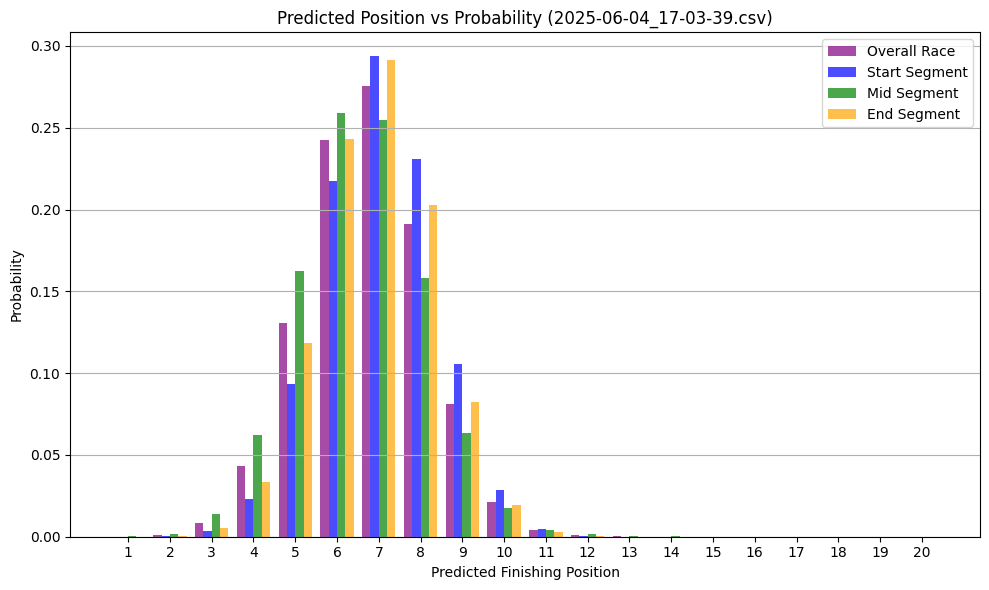

In [7]:
run_multiple_experiments(n_runs=100, train_size_ratio=0.8, normalize=True, optimize_hyperparameters=True)